# MNIST NET SNN

## Library Setup

In [1]:
import os, json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import tonic
import tonic.transforms as transforms
import datetime
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import confusion_matrix
import seaborn as sns

import lava.lib.dl.slayer as slayer

c:\Users\murfe\Desktop\Borsa\syntzulu_new\.conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No CUDA runtime is found, using CUDA_HOME='C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.9'


## Hyperparameter

In [2]:
T = 48                 # passi temporali
BATCH_SIZE = 32
EARLY_STOP_PATIENCE = 3
EPOCHS = 5
LR = 5e-4

NMNIST_HW_P = (34, 34, 2)     # (W,H,P) nativo N-MNIST
TARGET_HW  = (8, 8)         # (W,H) target hardware

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)

print(f"Device: {DEVICE}")

trained_folder = "./trained_snn"

Device: cpu


## Dataset Preparation

In [3]:
from torch.utils.data import random_split

# Ricampionatura geometrica scalata 
down_to_16 = transforms.Downsample(sensor_size=NMNIST_HW_P,
                                   target_size=TARGET_HW)
to_frame   = transforms.ToFrame(sensor_size=(TARGET_HW[0], TARGET_HW[1], 2),
                                n_time_bins=T)

train_tf = transforms.Compose([down_to_16, to_frame])
test_tf  = transforms.Compose([down_to_16, to_frame])

# Dataset completo di training
full_train_set = tonic.datasets.NMNIST(save_to="./data", train=True, transform=train_tf)

# Suddivisione 85/15 
train_size = int(0.85 * len(full_train_set))
val_size   = len(full_train_set) - train_size

train_set, validation_set = random_split(full_train_set, [train_size, val_size])

# Dataset di test (standard)
test_set = tonic.datasets.NMNIST(save_to="./data", train=False, transform=test_tf)

print(f"Train: {len(train_set)} campioni")
print(f"Validation: {len(validation_set)} campioni")
print(f"Test: {len(test_set)} campioni")


Train: 51000 campioni
Validation: 9000 campioni
Test: 10000 campioni


In [4]:
def collate_chwt(batch): #Converte numpy → torch, riordina assi per ottenere (P,H,W,T), poi stack su batch → (N,P,H,W,T).
    xs, ys = zip(*batch)
    xs = [torch.from_numpy(x).permute(1,2,3,0).contiguous().float() for x in xs]  # (P,H,W,T)
    X  = torch.stack(xs, dim=0)   # (N,P,H,W,T)
    y  = torch.tensor(ys, dtype=torch.long)
    return X, y

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, collate_fn=collate_chwt)
validation_loader = DataLoader(validation_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, collate_fn=collate_chwt)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True, collate_fn=collate_chwt)

xb, yb = next(iter(train_loader))
print("Batch shape (N,C,H,W,T):", xb.shape)  # atteso: (B, 2, 16, 16, T)

Batch shape (N,C,H,W,T): torch.Size([32, 2, 8, 8, 48])


## SNN definition and training

In [5]:
import torch
import torch.nn as nn
import lava.lib.dl.slayer as slayer

class Network(nn.Module):
    def __init__(self, n_classes=10, neuron_params=None):
        super().__init__()
        if neuron_params is None:
            neuron_params = dict(
                threshold=0.4,
                current_decay=0.4,
                voltage_decay=0.25,
                tau_grad=0.03,
                scale_grad=3,
                requires_grad=True,
            )

        # Input: (2,8,8)
        self.c1 = slayer.block.cuba.Conv(neuron_params, 2, 16, kernel_size=3, stride=1, padding=1)  # -> (8,8,8)
        self.c2 = slayer.block.cuba.Conv(neuron_params, 16, 2, kernel_size=3, stride=1, padding=0)  # -> (2,8,8)

        self.flat = slayer.block.cuba.Flatten()                 # -> (128, T)
        self.fc1  = slayer.block.cuba.Dense(neuron_params, 72, 64)
        self.out  = slayer.block.cuba.Dense(neuron_params, 64, n_classes)

        self.blocks = [self.c1, self.c2, self.fc1, self.out]

    def forward(self, x):
        # Se i tuoi input sono ancora 16x16, taglia qui:
        # x = x[:, :, :8, :8, :]   # (N,2,8,8,T)

        x = self.c1(x)
        x = self.c2(x)
        x = self.flat(x)  # 2*8*8 = 128
        x = self.fc1(x)
        x = self.out(x)
        return x

    # monitoraggio potenziale
    @torch.no_grad()
    def potential_monitor(self, x): # Abilita persistent_state per accumulare stati neurali nel tempo.
        for b in self.blocks:
            b.neuron.persistent_state = True

        vmins, vmaxs = {}, {}
        T = x.shape[-1]
        for t in range(T):
            xt = x[..., :t+1]
            y = self.c1(xt)
            y = self.c2(y)
            y = self.flat(y)
            y = self.fc1(y)
            y = self.out(y)
            for name, b in [('c1',self.c1),('c2',self.c2),('fc1',self.fc1),('out',self.out)]:
                v = b.neuron.voltage_state.detach().cpu()
                vmin = v.min().item(); vmax = v.max().item()
                if name not in vmins or vmin < vmins[name]: vmins[name] = vmin
                if name not in vmaxs or vmax > vmaxs[name]: vmaxs[name] = vmax
        for b in self.blocks:
            b.neuron.persistent_state = False
        return {k:(vmins[k],vmaxs[k]) for k in vmins.keys()}

    # tracciamento correnti, potenziali, spike
    @torch.no_grad()
    def trace_all(self, x): #Funzione di debug: ricostruisce I (corrente), V (potenziale) e S (spike binari) per ogni layer.
        traces = {}
        h = x
        for name, layer in [('c1',self.c1),('c2',self.c2)]:
            s = layer(h)
            w_spk = layer.synapse.forward(h)
            I, V = layer.neuron.dynamics(w_spk)
            S = (V >= layer.neuron.threshold).to(V.dtype)
            traces[name] = {'I': I.cpu(), 'V': V.cpu(), 'S': S.cpu()}
            h = s

        h_flat = self.flat(h)
        for name, layer in [('fc1',self.fc1),('out',self.out)]:
            s = layer(h_flat)
            w_spk = layer.synapse.forward(h_flat)
            I, V = layer.neuron.dynamics(w_spk)
            S = (V >= layer.neuron.threshold).to(V.dtype)
            traces[name] = {'I': I.cpu(), 'V': V.cpu(), 'S': S.cpu()}
            h_flat = s

        yhat = self.forward(x)
        return yhat, traces


In [6]:
data = str(datetime.datetime.now())
data = ((data[0:16].replace(" ", "_")).replace("-","_")).replace(":","_")

os.makedirs(trained_folder, exist_ok=True)

In [7]:
print("Device:", DEVICE)

net = Network(n_classes=10).to(DEVICE)

# loss & trainer SLAYER consigliati per N-MNIST LAVA
error     = slayer.loss.SpikeRate(true_rate=0.20, false_rate=0.03, reduction='sum').to(DEVICE)
optimizer = torch.optim.Adam(net.parameters(), lr=LR, weight_decay=1e-5)
stats     = slayer.utils.LearningStats()

assistant = slayer.utils.Assistant(
    net=net,
    error=error,
    optimizer=optimizer,
    stats=stats,
    classifier=slayer.classifier.Rate.predict,
    count_log=False,
)


Device: cpu


In [8]:
print(net)

Network(
  (c1): Conv(
    (neuron): Neuron()
    (synapse): Conv(2, 16, kernel_size=(3, 3, 1), stride=(1, 1, 1), padding=(1, 1, 0), bias=False)
  )
  (c2): Conv(
    (neuron): Neuron()
    (synapse): Conv(16, 2, kernel_size=(3, 3, 1), stride=(1, 1, 1), bias=False)
  )
  (flat): Flatten()
  (fc1): Dense(
    (neuron): Neuron()
    (synapse): Dense(72, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
  )
  (out): Dense(
    (neuron): Neuron()
    (synapse): Dense(64, 10, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
  )
)


In [9]:
best_epoch = -1
best_loss  = float("inf")

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5, verbose=True, min_lr=1e-5
)


### TRAINING LOOP

In [91]:
for epoch in range(EPOCHS):
    # train 
    net.train()
    for i, (xb, yb) in enumerate(train_loader):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        _ = assistant.train(xb, yb)
        print(f"\r[Epoch {epoch+1:3d}/{EPOCHS}] [{i+1:4d}/{len(train_loader)}] {stats}", end="")
    print()

    #  validate 
    net.eval()
    with torch.no_grad():
        for xb, yb in validation_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            _ = assistant.test(xb, yb)

    val_loss = stats.testing.loss
    train_loss = stats.training.loss
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    # checkpoint "last"
    torch.save(net.state_dict(), os.path.join(trained_folder, "network_last.pt"))

    # checkpoint "best"
    if val_loss < best_loss:
        best_loss  = val_loss
        best_epoch = epoch
        torch.save(net.state_dict(), os.path.join(trained_folder, "network_best_padding.pt"))
        with open(os.path.join(trained_folder, "best_epoch.txt"), "w") as f:
            f.write(str(best_epoch))
        no_improve = 0
    else:
        no_improve += 1

    stats.save(trained_folder + "/")
    stats.update()
    scheduler.step(val_loss)

    if no_improve >= EARLY_STOP_PATIENCE:
        print(f"Early stop at epoch {epoch+1} (best @ {best_epoch+1}, val_loss={best_loss:.4f})")
        break

print(f"Finished. Best epoch = {best_epoch+1 if best_epoch>=0 else 'n/a'}")


[Epoch   1/5] [1594/1594] Train loss =     1.19840                        accuracy = 0.45765
Epoch 1: train_loss=1.1984  val_loss=0.7435
[Epoch   2/5] [1594/1594] Train loss =     0.62943 (min =     1.19840)    accuracy = 0.70945 (max = 0.45765)
Epoch 2: train_loss=0.6294  val_loss=0.5930
[Epoch   3/5] [1594/1594] Train loss =     0.57573 (min =     0.62943)    accuracy = 0.77257 (max = 0.70945)
Epoch 3: train_loss=0.5757  val_loss=0.4815
[Epoch   4/5] [1594/1594] Train loss =     0.53963 (min =     0.57573)    accuracy = 0.80424 (max = 0.77257)
Epoch 4: train_loss=0.5396  val_loss=0.4817
[Epoch   5/5] [1594/1594] Train loss =     0.49970 (min =     0.53963)    accuracy = 0.82798 (max = 0.80424)
Epoch 5: train_loss=0.4997  val_loss=0.4868
Finished. Best epoch = 3


## Continuous Inference 

In [10]:
MODEL_PATH     = os.path.join(trained_folder, 'network_best_padding.pt')

net = Network(n_classes=10)
net.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
net.eval()
print("✅ Modello caricato:", MODEL_PATH)

✅ Modello caricato: ./trained_snn\network_best_padding.pt


In [11]:
spike_stream = torch.zeros((1,2,8,8,12))
spike_stream[0,0,:,:,:] = (torch.rand((8,8,12)) > 0.9).float()

# Inferenza
with torch.no_grad():
    out = net(spike_stream).cpu().numpy()
print("Output shape:", out.shape)
print("Max:", out.max(), "Mean:", out.mean())

# Potenziali
pot = net.potential_monitor(spike_stream)
print(pot)


Output shape: (1, 10, 12)
Max: 0.0 Mean: 0.0
{'c1': (-2.254150390625, 0.390380859375), 'c2': (-5.646728515625, 0.38037109375), 'fc1': (-4.359375, 0.389892578125), 'out': (-0.06201171875, 0.18896484375)}


In [12]:
@torch.no_grad()
def debug_activity(net, x):
    layers = [
        ('c1', net.c1),
        ('c2', net.c2),
        ('fc1', net.fc1),
        ('out', net.out),
    ]

    h = x
    print("---- Activity Debug ----")
    for name, layer in layers:
        if name == 'fc1':
            h = net.flat(h)
        s = layer(h)
        n_spikes = s.sum().item()
        v_max = layer.neuron.voltage_state.max().item() if hasattr(layer.neuron, "voltage_state") else 0
        print(f"{name}: spikes={n_spikes:.1f}, Vmax={v_max:.3f}")
        h = s

spike_stream[0,0,:,:,:] = (torch.rand((8,8,12)) > 0.9).float()
debug_activity(net, spike_stream)


---- Activity Debug ----
c1: spikes=445.0, Vmax=0.389
c2: spikes=14.0, Vmax=0.353
fc1: spikes=1.0, Vmax=0.232
out: spikes=0.0, Vmax=0.042


→ Esempio trovato per label 9
→ Input shape: (1, 2, 8, 8, 48)
→ Predizione rete: classe 9 (target = 9)
Output shape: (10, 48)


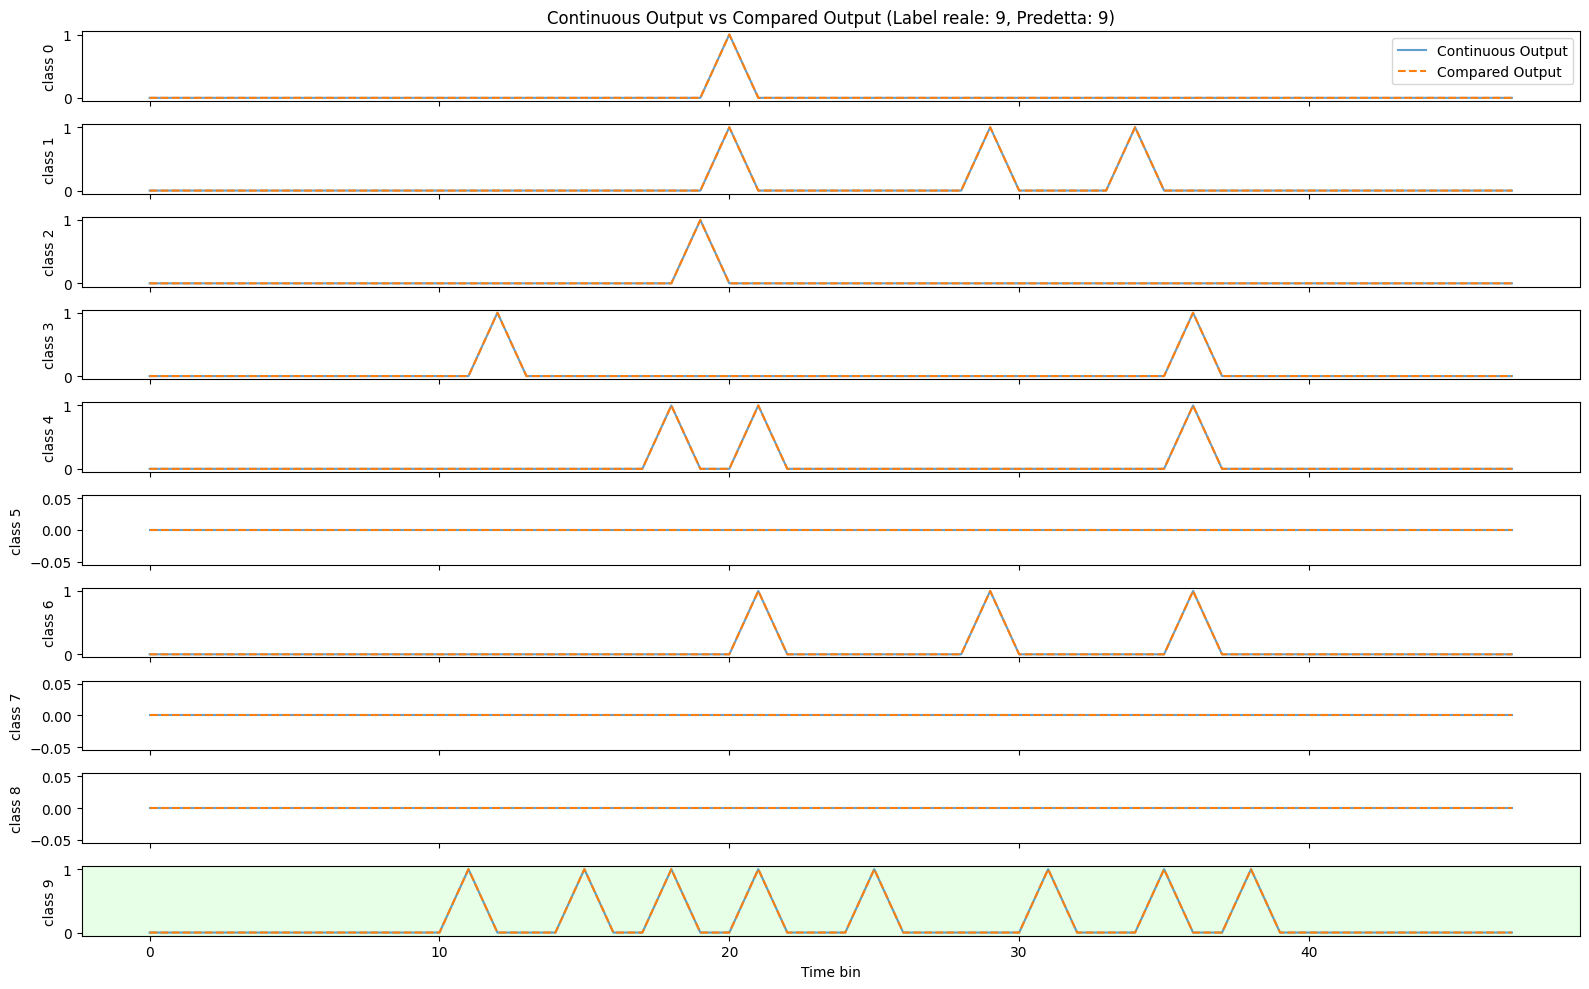

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# PARAMETRI 
N_CLASSES = 10
TARGET_LABEL = 9
net.eval()

for data, label in test_loader:
    idx = (label == TARGET_LABEL).nonzero(as_tuple=True)[0]
    if len(idx) > 0:
        spike_stream = data[idx[0]:idx[0]+1].to(torch.float32).to(DEVICE)
        real_label = int(label[idx[0]].item())
        break
else:
    raise ValueError(f"Nessun esempio trovato con label {TARGET_LABEL}!")

print(f"→ Esempio trovato per label {real_label}")
print(f"→ Input shape: {tuple(spike_stream.shape)}")

with torch.no_grad():
    continuous_output = net(spike_stream).cpu().detach().numpy()

continuous_output = np.squeeze(continuous_output)
if continuous_output.ndim != 2:
    continuous_output = continuous_output.reshape(N_CLASSES, -1)

rates = continuous_output.sum(axis=-1)
pred_class = int(np.argmax(rates))
print(f"→ Predizione rete: classe {pred_class} (target = {real_label})")
print(f"Output shape: {continuous_output.shape}")

newOne, newZero = 1.0, 0.0
compared_continuous_output = np.copy(continuous_output)

max_per_class = np.maximum(np.max(np.abs(continuous_output), axis=-1, keepdims=True), 1e-6)
normed = continuous_output / max_per_class
compared_continuous_output[normed <= 0.75] = newZero
compared_continuous_output[normed >  0.75] = newOne

# PLOT
fig, axs = plt.subplots(N_CLASSES, 1, figsize=(16, 10), sharex=True)
labels = [f'class {i}' for i in range(N_CLASSES)]

for i in range(N_CLASSES):
    axs[i].plot(continuous_output[i], label='Continuous Output', alpha=0.7)
    axs[i].plot(compared_continuous_output[i], label='Compared Output', linestyle='--')
    axs[i].set_ylabel(labels[i])
    if i == pred_class:
        axs[i].set_facecolor((0.9, 1.0, 0.9))  # evidenzia la classe predetta

axs[0].set_title(f'Continuous Output vs Compared Output (Label reale: {real_label}, Predetta: {pred_class})')
axs[-1].set_xlabel('Time bin')
axs[0].legend(loc='upper right')
plt.tight_layout()
plt.show()


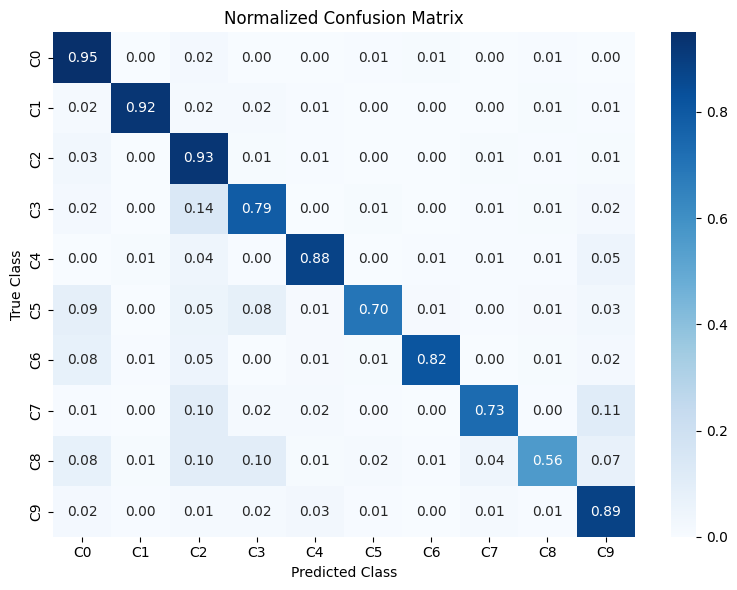

Accuratezza media: 81.59%


In [14]:
all_preds, all_labels = [], []
net.eval()

with torch.no_grad():
    for xb, yb in test_loader:
        out = net(xb.to(DEVICE)).cpu().numpy().sum(axis=-1)  # somma su T → spike rate
        all_preds += np.argmax(out, axis=1).tolist()
        all_labels += yb.tolist()

# === MATRICE DI CONFUSIONE NORMALIZZATA ===
cm = confusion_matrix(all_labels, all_preds, normalize='true')  # normalizza per riga (classe reale)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=[f"C{i}" for i in range(cm.shape[0])],
            yticklabels=[f"C{i}" for i in range(cm.shape[0])])
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

# === ACCURATEZZA MEDIA ===
acc = np.trace(cm) / len(cm)
print(f"Accuratezza media: {acc*100:.2f}%")

In [15]:
with torch.no_grad():
    out = net(spike_stream.to(DEVICE)).cpu().detach().numpy()
print("Output range:", out.min(), out.max(), out.mean())


Output range: 0.0 1.0 0.0375


## Potential Monitor

In [16]:
# ===============================================
# Costruzione input_vector coerente con simulazione SNN hardware
# ===============================================

net.eval()

best_examples = {}

# loop per ogni cifra da 0 a 9
for target_digit in range(10):
    found = False
    for data, labels in test_loader:
        data = data.to(torch.float32).to(DEVICE)
        with torch.no_grad():
            outputs = net(data).cpu().numpy()  # (batch, n_classes, T)
        outputs = np.squeeze(outputs)

        if outputs.ndim == 2:
            outputs = outputs.reshape(-1, 10, outputs.shape[-1])

        rates = outputs.sum(axis=-1)
        preds = np.argmax(rates, axis=1)

        for i in range(len(labels)):
            true = int(labels[i].item())
            pred = int(preds[i])
            if true == target_digit and pred == true:
                best_examples[target_digit] = data[i:i+1].cpu()
                print(f"✔️ Digit {target_digit} riconosciuto correttamente.")
                found = True
                break
        if found:
            break

print("\nCampioni trovati per:", sorted(best_examples.keys()))

✔️ Digit 0 riconosciuto correttamente.
✔️ Digit 1 riconosciuto correttamente.
✔️ Digit 2 riconosciuto correttamente.
✔️ Digit 3 riconosciuto correttamente.
✔️ Digit 4 riconosciuto correttamente.
✔️ Digit 5 riconosciuto correttamente.
✔️ Digit 6 riconosciuto correttamente.
✔️ Digit 7 riconosciuto correttamente.
✔️ Digit 8 riconosciuto correttamente.
✔️ Digit 9 riconosciuto correttamente.

Campioni trovati per: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [17]:
# Stack delle 10 classi
spike_batch = torch.stack([best_examples[i].squeeze(0) for i in range(10)], dim=-1)  # (2,8,8,T,10)
spike_batch = spike_batch.permute(3, 0, 1, 2, 4).contiguous()                        # (T,2,8,8,10)

# Clamping per garantire spike binari
spike_batch = torch.clamp(spike_batch, 0, 1)

# Conversione in numpy se serve
input_vector = spike_batch.cpu().numpy().astype(np.int8)

print(f"\n✅ input_vector shape: {input_vector.shape}")
print(f"   min={input_vector.min()} max={input_vector.max()}")
print(f"   valori unici: {np.unique(input_vector)}")



✅ input_vector shape: (48, 2, 8, 8, 10)
   min=0 max=1
   valori unici: [0 1]


In [18]:
spike_list = [best_examples[i] for i in range(10)]
label_list = list(range(10))

In [19]:
with torch.no_grad():
    continuous_output = net(spike_batch.to(DEVICE)).cpu().detach().numpy()

print("→ Continuous output shape:", continuous_output.shape)


→ Continuous output shape: (48, 10, 10)


In [20]:
import numpy as np
import torch

w_c1 = net.c1.synapse.weight.detach().cpu().numpy()
w_c2 = net.c2.synapse.weight.detach().cpu().numpy()
w_fc1 = net.fc1.synapse.weight.detach().cpu().numpy()
w_out = net.out.synapse.weight.detach().cpu().numpy()

def quantize_percentile(w_fp, p=99.5):
    s = np.percentile(np.abs(w_fp), p)
    if s == 0:
        s = np.max(np.abs(w_fp)) or 1.0
    scale = 127.0 / s
    w_q = np.clip(np.round(w_fp * scale), -128, 127).astype(np.int8)
    return w_q, scale

conv1_kernels, scale_c1 = quantize_percentile(w_c1, p=99.5)
conv2_kernels, scale_c2 = quantize_percentile(w_c2, p=99.5)
fc1_weights,   scale_fc1 = quantize_percentile(w_fc1, p=99.5)
out_weights,   scale_out = quantize_percentile(w_out, p=99.5)


def stats(name, w):
    w = np.array(w, dtype=np.int8)
    clip_ratio = np.mean((w == -128) | (w == 127)) * 100
    print(f"{name:8s} → min={w.min():4d}  max={w.max():4d}  mean={w.mean():7.2f}  std={w.std():7.2f}  clip={clip_ratio:5.2f}%")

print("\n=== SCALE USATE ===")
print(f"Conv1: {scale_c1:.4f}")
print(f"Conv2: {scale_c2:.4f}")
print(f"FC1  : {scale_fc1:.4f}")
print(f"OUT  : {scale_out:.4f}")

stats("Conv1", conv1_kernels)
stats("Conv2", conv2_kernels)
stats("FC1",   fc1_weights)
stats("OUT",   out_weights)

BITS_THR   = 15  # soglia
BITS_DECAY = 12  # decay

# Estrai i valori float dal modello
thr = np.array([
    float(net.c1.neuron.threshold),
    float(net.c2.neuron.threshold),
    float(net.fc1.neuron.threshold),
    float(net.out.neuron.threshold)
])

vdec = np.array([
    float(net.c1.neuron.voltage_decay.detach().cpu().numpy()[0]),
    float(net.c2.neuron.voltage_decay.detach().cpu().numpy()[0]),
    float(net.fc1.neuron.voltage_decay.detach().cpu().numpy()[0]),
    float(net.out.neuron.voltage_decay.detach().cpu().numpy()[0])
])

cdec = np.array([
    float(net.c1.neuron.current_decay.detach().cpu().numpy()[0]),
    float(net.c2.neuron.current_decay.detach().cpu().numpy()[0]),
    float(net.fc1.neuron.current_decay.detach().cpu().numpy()[0]),
    float(net.out.neuron.current_decay.detach().cpu().numpy()[0])
])

# Conversione in dominio HW
THR_MAX   = (1 << BITS_THR) - 1
DECAY_MAX = (1 << BITS_DECAY) - 1

# Applica la scala dei pesi per ogni layer (senza saturazione finale)
thr_hw = np.round(thr * np.array([scale_c1, scale_c2, scale_fc1, scale_out])).astype(np.int32)
thr_hw = np.clip(thr_hw, 0, THR_MAX)  # evita overflow, ma nessuna forzatura al massimo

vdec_hw = np.round(vdec).astype(np.int32)
cdec_hw = np.round(cdec).astype(np.int32)

print("\n=== PARAMETRI NEURONALI (bit-precisi, senza saturazione) ===")
for i, (t, tv, tc) in enumerate(zip(thr_hw, vdec_hw, cdec_hw), 1):
    print(f"Layer {i:>2d} → THR={t:6d}  VDEC={tv:4d}  CDEC={tc:4d}")

print("\nPesi e parametri quantizzati pronti per deploy\n")


=== SCALE USATE ===
Conv1: 423.0848
Conv2: 771.6115
FC1  : 564.2748
OUT  : 1211.3963
Conv1    → min=-128  max= 127  mean=  -4.67  std=  57.63  clip= 0.69%
Conv2    → min=-128  max= 127  mean=  -7.83  std=  41.01  clip= 0.69%
FC1      → min=-128  max= 114  mean=  -6.85  std=  39.30  clip= 0.50%
OUT      → min=-128  max= 127  mean=   4.77  std=  41.74  clip= 0.62%

=== PARAMETRI NEURONALI (bit-precisi, senza saturazione) ===
Layer  1 → THR=   165  VDEC=1023  CDEC=1638
Layer  2 → THR=   301  VDEC=1024  CDEC=1638
Layer  3 → THR=   220  VDEC=1024  CDEC=1638
Layer  4 → THR=   473  VDEC=1024  CDEC=1638

Pesi e parametri quantizzati pronti per deploy



In [21]:
import numpy as np
import torch

w_c1 = net.c1.synapse.weight.detach().cpu().numpy()
w_c2 = net.c2.synapse.weight.detach().cpu().numpy()
w_fc1 = net.fc1.synapse.weight.detach().cpu().numpy()
w_out = net.out.synapse.weight.detach().cpu().numpy()

def quantize_percentile(w_fp, p=99.5):
    s = np.percentile(np.abs(w_fp), p)
    if s == 0:
        s = np.max(np.abs(w_fp)) or 1.0
    scale = 127.0 / s
    w_q = np.clip(np.round(w_fp * scale), -128, 127).astype(np.int8)
    return w_q, scale

conv1_kernels, scale_c1 = quantize_percentile(w_c1, p=99.5)
conv2_kernels, scale_c2 = quantize_percentile(w_c2, p=99.5)
fc1_weights,   scale_fc1 = quantize_percentile(w_fc1, p=99.5)
out_weights,   scale_out = quantize_percentile(w_out, p=99.5)


def stats(name, w):
    w = np.array(w, dtype=np.int8)
    clip_ratio = np.mean((w == -128) | (w == 127)) * 100
    print(f"{name:8s} → min={w.min():4d}  max={w.max():4d}  mean={w.mean():7.2f}  std={w.std():7.2f}  clip={clip_ratio:5.2f}%")

print("\n=== SCALE USATE ===")
print(f"Conv1: {scale_c1:.4f}")
print(f"Conv2: {scale_c2:.4f}")
print(f"FC1  : {scale_fc1:.4f}")
print(f"OUT  : {scale_out:.4f}")

stats("Conv1", conv1_kernels)
stats("Conv2", conv2_kernels)
stats("FC1",   fc1_weights)
stats("OUT",   out_weights)

BITS_THR   = 15  # soglia
BITS_DECAY = 12  # decay

# Estrai i valori float dal modello
thr = np.array([
    float(net.c1.neuron.threshold),
    float(net.c2.neuron.threshold),
    float(net.fc1.neuron.threshold),
    float(net.out.neuron.threshold)
])

vdec = np.array([
    float(net.c1.neuron.voltage_decay.detach().cpu().numpy()[0]),
    float(net.c2.neuron.voltage_decay.detach().cpu().numpy()[0]),
    float(net.fc1.neuron.voltage_decay.detach().cpu().numpy()[0]),
    float(net.out.neuron.voltage_decay.detach().cpu().numpy()[0])
])

cdec = np.array([
    float(net.c1.neuron.current_decay.detach().cpu().numpy()[0]),
    float(net.c2.neuron.current_decay.detach().cpu().numpy()[0]),
    float(net.fc1.neuron.current_decay.detach().cpu().numpy()[0]),
    float(net.out.neuron.current_decay.detach().cpu().numpy()[0])
])

# Conversione in dominio HW
THR_MAX   = (1 << BITS_THR) - 1
DECAY_MAX = (1 << BITS_DECAY) - 1

# Applica la scala dei pesi per ogni layer (senza saturazione finale)
thr_hw = np.round(thr * np.array([scale_c1, scale_c2, scale_fc1, scale_out])).astype(np.int32)
thr_hw = np.clip(thr_hw, 0, THR_MAX)  # evita overflow, ma nessuna forzatura al massimo

vdec_hw = np.round(vdec).astype(np.int32)
cdec_hw = np.round(cdec).astype(np.int32)

print("\n=== PARAMETRI NEURONALI (bit-precisi, senza saturazione) ===")
for i, (t, tv, tc) in enumerate(zip(thr_hw, vdec_hw, cdec_hw), 1):
    print(f"Layer {i:>2d} → THR={t:6d}  VDEC={tv:4d}  CDEC={tc:4d}")

print("\nPesi e parametri quantizzati pronti per deploy\n")


=== SCALE USATE ===
Conv1: 423.0848
Conv2: 771.6115
FC1  : 564.2748
OUT  : 1211.3963
Conv1    → min=-128  max= 127  mean=  -4.67  std=  57.63  clip= 0.69%
Conv2    → min=-128  max= 127  mean=  -7.83  std=  41.01  clip= 0.69%
FC1      → min=-128  max= 114  mean=  -6.85  std=  39.30  clip= 0.50%
OUT      → min=-128  max= 127  mean=   4.77  std=  41.74  clip= 0.62%

=== PARAMETRI NEURONALI (bit-precisi, senza saturazione) ===
Layer  1 → THR=   165  VDEC=1023  CDEC=1638
Layer  2 → THR=   301  VDEC=1024  CDEC=1638
Layer  3 → THR=   220  VDEC=1024  CDEC=1638
Layer  4 → THR=   473  VDEC=1024  CDEC=1638

Pesi e parametri quantizzati pronti per deploy



In [22]:
THRESH_C1 = int(np.round(thr[0] * scale_c1))
THRESH_C2 = int(np.round(thr[1] * scale_c2))
THRESH_FC1 = int(np.round(thr[2] * scale_fc1))
THRESH_OUT = int(np.round(thr[3] * scale_out))

print (THRESH_C1)
print (THRESH_C2)
print (THRESH_FC1)
print (THRESH_OUT)

165
301
220
473


## DEPLOYMENT

In [23]:
class Deployment:
    def __init__(self, n_inputs, n_classes, Nsamples):
        self.n_inputs = n_inputs
        self.n_classes = n_classes
        self.Nsamples = Nsamples
        self.layers = 4

    def set_weights(self, w_c1, w_c2, w_fc1, w_out):
        self.w_c1 = w_c1
        self.w_c2 = w_c2
        self.w_fc1 = w_fc1
        self.w_out = w_out

    def set_params(self, current_decay, voltage_decay, threshold):
        self.current_decay = current_decay
        self.voltage_decay = voltage_decay
        self.threshold = threshold

    def set_delays(self, d_c1, d_c2, d_fc1, d_out):
        self.d_c1 = d_c1
        self.d_c2 = d_c2
        self.d_fc1 = d_fc1
        self.d_out = d_out

    def set_test_vectors(self, label, input_vec, output_vec):
        self.label = label
        self.input_vec = input_vec
        self.output_vec = output_vec


In [24]:
N = T  # numero di timesteps
deploy = Deployment(n_inputs=2, n_classes=10, Nsamples=N)

deploy.set_weights(
    torch.from_numpy(conv1_kernels),  # già quantizzati
    torch.from_numpy(conv2_kernels),
    torch.from_numpy(fc1_weights),
    torch.from_numpy(out_weights)
)

current_decay_hw = torch.tensor(cdec_hw, dtype=torch.int32)
voltage_decay_hw = torch.tensor(vdec_hw, dtype=torch.int32)
threshold_hw     = torch.tensor(thr_hw, dtype=torch.int32)

deploy.set_params(current_decay_hw, voltage_decay_hw, threshold_hw)

deploy.set_delays(
    torch.zeros(net.c1.synapse.weight.shape[0]).int(),
    torch.zeros(net.c2.synapse.weight.shape[0]).int(),
    torch.zeros(net.fc1.synapse.weight.shape[0]).int(),
    torch.zeros(net.out.synapse.weight.shape[0]).int()
)

deploy.set_test_vectors(
    label_list,
    spike_batch,
    torch.tensor(continuous_output.squeeze())
)

deploy_path = os.path.join(trained_folder, "deployment_conv_dense.obj")
with open(deploy_path, "wb") as f:
    pickle.dump(deploy, f)

print(f"\nDeployment object salvato in: {deploy_path}")
print("   (contiene pesi e parametri già quantizzati per hardware)")


Deployment object salvato in: ./trained_snn\deployment_conv_dense.obj
   (contiene pesi e parametri già quantizzati per hardware)


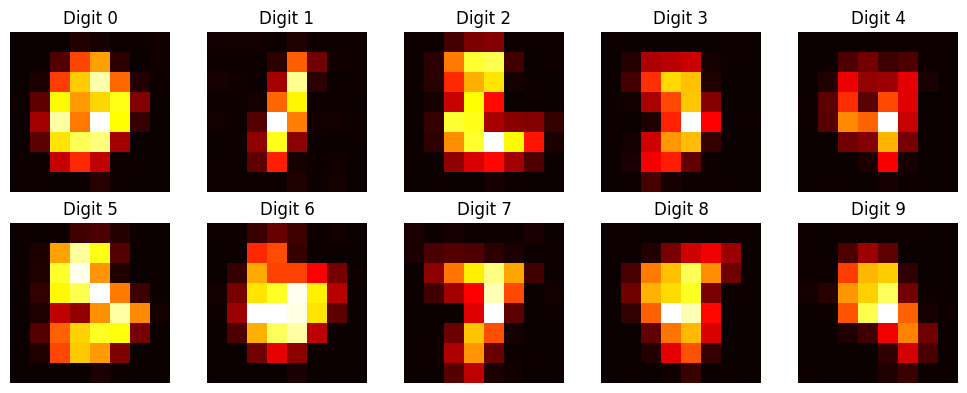

In [25]:
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
for i in range(10):
    spikes = spike_list[i][0].cpu().numpy()  # (2,16,16,T)
    spike_map = np.sum(spikes, axis=-1).sum(axis=0)
    ax = axs[i//5, i%5]
    ax.imshow(spike_map, cmap='hot')
    ax.set_title(f"Digit {label_list[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()


In [26]:
import torch
import numpy as np
import pandas as pd
from IPython.display import display

# ===============================
# PARAMETRI
# ===============================

N_CLASSES = 10
net.eval()

# ===============================
# 1️⃣ COSTRUISCI LISTE DAGLI ESEMPI TROVATI
# ===============================
spike_list = [best_examples[i] for i in range(10) if i in best_examples]
label_list = [i for i in range(10) if i in best_examples]

# ===============================
# 2️⃣ INFERENZA E TABULAZIONE
# ===============================
results = []

for real_label, spike_stream in zip(label_list, spike_list):
    spike_stream = spike_stream.to(torch.float32).to(DEVICE)

    with torch.no_grad():
        continuous_output = net(spike_stream).cpu().detach().numpy()

    continuous_output = np.squeeze(continuous_output)
    if continuous_output.ndim != 2:
        continuous_output = continuous_output.reshape(N_CLASSES, -1)

    # rate decoding
    rates = continuous_output.sum(axis=-1)
    pred_class = int(np.argmax(rates))

    results.append({
        'Digit reale': real_label,
        'Predizione': pred_class,
        'Corretta': (real_label == pred_class)
    })

# ===============================
# 🧾 3️⃣ TABELLA RISULTATI
# ===============================
df_results = pd.DataFrame(results)
df_results['✔️'] = df_results['Corretta'].apply(lambda x: '✅' if x else '❌')

display(
    df_results.style
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])
    .hide(axis="index")
)

print("\nAccuratezza totale:", round(df_results['Corretta'].mean() * 100, 2), "%")


Digit reale,Predizione,Corretta,✔️
0,0,True,✅
1,1,True,✅
2,2,True,✅
3,3,True,✅
4,4,True,✅
5,5,True,✅
6,6,True,✅
7,7,True,✅
8,8,True,✅
9,9,True,✅



Accuratezza totale: 100.0 %
